In [23]:
import sys
import healpy as hp
import numpy as np
sys.path.insert(0,"../..")
import select_and_orient as sao
import glob
import stacking_functions as sf
from pixell import enmap, enplot, reproject, utils
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
orient_catalog = "/mnt/raid-cita/mlokken/data/desi/LRG_clustering.dat.fits"
stack_catalog  = "/mnt/raid-cita/mlokken/data/desi/LRG_clustering_Y1_zred_desi_complete_thresh0.7_excl0.4deg_ACTmasked.fits"
ra_oo, dec_oo, z_oo, w_oo = sao.get_radecz(orient_catalog, return_weight=True)
ra_so, dec_so, z_so, w_so = sao.get_radecz(stack_catalog, return_weight=True)
ra_rand = []
dec_rand = []
z_rand = []
w_rand = []
randoms = glob.glob("/mnt/raid-cita/mlokken/data/desi/randoms/LRG_*_clustering.ran.fits")
for ranfile in randoms:
    ra_rand_i, dec_rand_i, z_rand_i, w_rand_i = sao.get_radecz(ranfile, return_weight=True)
    ra_rand.extend(ra_rand_i)
    dec_rand.extend(dec_rand_i)
    z_rand.extend(z_rand_i)
    w_rand.extend(w_rand_i)


DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.
DESI LRG catalog entered.


In [4]:
ra_rand = np.array(ra_rand)
dec_rand = np.array(dec_rand)
z_rand = np.array(z_rand)
w_rand = np.array(w_rand)


In [5]:
zmin = 0.6
zmax = 0.61
inz_oo = (z_oo<zmax) & (z_oo>zmin)
inz_rand = (z_rand<zmax) & (z_rand>zmin)

In [9]:
ra_rand_inz = ra_rand[inz_rand]
dec_rand_inz = dec_rand[inz_rand]
w_rand_inz = w_rand[inz_rand]
ra_oo_inz = ra_oo[inz_oo]
dec_oo_inz = dec_oo[inz_oo]
w_oo_inz = w_oo[inz_oo]
del ra_rand, dec_rand, z_rand, w_rand, z_oo, w_oo, ra_oo, dec_oo

NameError: name 'ra_rand' is not defined

sum data 44505.59191930044 sum rand 3179070.525677029
alpha is 0.013999561054035558
Min of randoms within threhsold is 0.20212138655441958
Mean smoothed diff -3.739262142149621e-06 Mean smoothed rand 3.6900582454343605 Mean smoothed data 0.05165545643776352 ratio data to rand with alpha 0.9999276167177696
Mean data: 0.05175435922699218
Mean rand: 3.6968300669453678
Mean of delta map is 7.222569702189828e-05


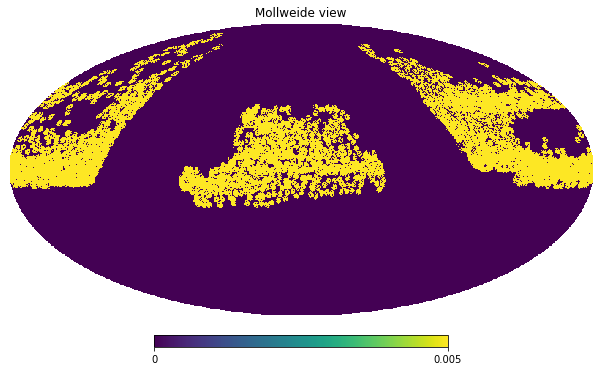

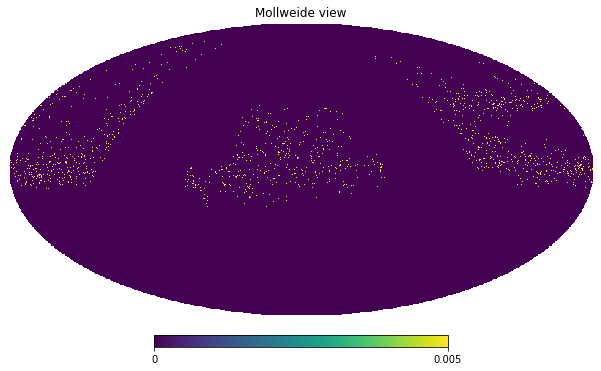

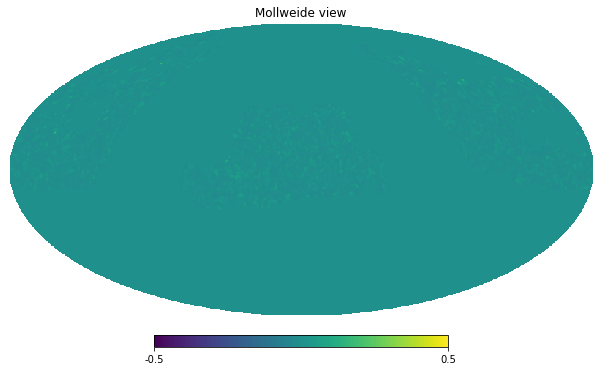

In [50]:
nside = 512
deltag = sao.delta_g(nside, ra_oo_inz, dec_oo_inz, ra_rand=ra_rand_inz, dec_rand=dec_rand_inz, catalog_weights=w_oo_inz, randoms_weights=w_rand_inz, alpha=1, smth=60, beam='gaussian') 

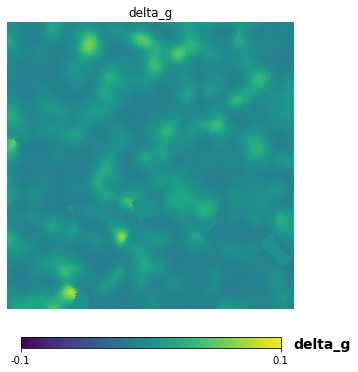

In [51]:
ra_range = [0,20]
dec_range = [-10,10]
deltag_cartmap = hp.cartview(deltag, title="delta_g", unit="delta_g", min=-.1, max=.1, lonra=ra_range, latra=dec_range, return_projected_map=True)

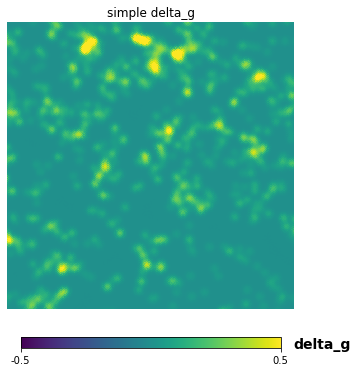

In [52]:
# compare to a simple map
deltamap_2 = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, ra_oo_inz, dec_oo_inz, lonlat=True)
np.add.at(deltamap_2, pix, w_oo_inz)
smth_deltamap_2 = hp.smoothing(deltamap_2, fwhm=np.radians(30/60))
hp.cartview(smth_deltamap_2, title="simple delta_g", unit="delta_g", min=-.5, max=.5, lonra=[0,20], latra=[-10,10])

In [53]:
# convert delta_g to enmap
# set up an empty enmap geometry
shape,wcs = enmap.fullsky_geometry(res=5 * utils.arcmin,proj='car')
deltag_enmap = reproject.healpix2map(deltag, shape=shape, wcs=wcs)

In [54]:
npix  = hp.nside2npix(nside)
th, ph = hp.pixelfunc.pix2ang(nside, np.arange(npix))
cotth = np.cos(th)/np.sin(th)

In [55]:
in_so_bin = (z_so<0.608)&(z_so>0.602)
z_so_bin = z_so[in_so_bin]
ra_so_bin = ra_so[in_so_bin]
dec_so_bin = dec_so[in_so_bin]
w_so_bin  = w_so[in_so_bin]

NameError: name 'z_so' is not defined

In [16]:
del z_so, ra_so, dec_so, w_so

In [56]:
ra_cut, dec_cut, z_cut, ca, sa, alpha = sao.measure_orientation(ra_so_bin, dec_so_bin, z_so_bin, deltag, cotth, e_min=0.3, e_max=None, nu_min=2, mode='density')

(6259, 2, 2)
Computed rms of the field: 0.0066
(6259,) (6259,) (6259,)
(1051, 6259, 2) (1051, 2, 2)


In [57]:
from astropy import wcs
w = wcs.WCS(naxis=2)

height = float(deltag_cartmap.shape[0])
length = float(deltag_cartmap.shape[1])
w = wcs.WCS(naxis=2)
cdeltaX, crvalX = (ra_range[0]-ra_range[1])/length, (ra_range[0]+ra_range[1])/2.
cdeltaY, crvalY = (dec_range[1]-dec_range[0])/height, (dec_range[0]+dec_range[1])/2.


w.wcs.crpix = length/2., height/2.
print(w.wcs.crpix)
w.wcs.crval = [crvalX,crvalY]
print(w.wcs.crval)
w.wcs.cdelt = np.array([cdeltaX,cdeltaY])
print(w.wcs.cdelt)
w.wcs.ctype = ["RA", "DEC"]

[400. 400.]
[10.  0.]
[-0.025  0.025]


In [58]:
def get_vector_components(rot_angle):
    # make it work for a single angle or an array of angles
    rot_angle = np.atleast_1d(rot_angle)
    U_arr = np.zeros(len(rot_angle))
    V_arr = np.zeros(len(rot_angle))
    m = 0
    for r in rot_angle:

        if (r <= np.pi/2.) or (r > 3*np.pi/2.):
            U = 1/np.sqrt(1+np.tan(r)**2)
        else:
            U = -1/np.sqrt(1+np.tan(r)**2)
        V = U * np.tan(r)
        U_arr[m] = U
        V_arr[m] = V
        m += 1
    return U_arr, V_arr

In [59]:
len(alpha)

1051

In [60]:
len(ra_cut)

1051

In [61]:
sel_area  = (ra_cut>ra_range[0])&(ra_cut<ra_range[1])&(dec_cut>dec_range[0])&(dec_cut<dec_range[1])
selection = sel_area
Xpix,Ypix = w.all_world2pix(ra_cut[selection], dec_cut[selection], 0)
U_arr, V_arr = get_vector_components(alpha[selection])

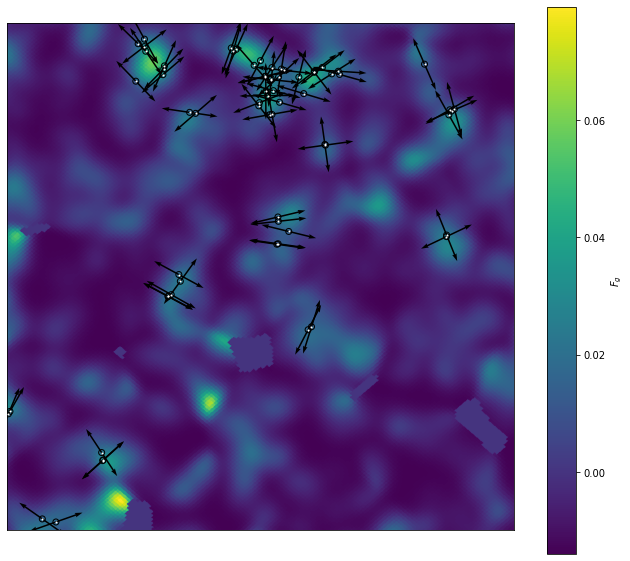

In [62]:
# Make the figure

fig = plt.figure(figsize=(20,20))

nrows = 2
ax1 = plt.subplot(1, 2, 1, projection=w)
# ax2 = plt.subplot(1, 2, 2, projection=w)

ax1.set_xticks([])
ax1.set_xticklabels([])

dmap = ax1.imshow(deltag_cartmap)


# plt.colorbar(sc1, cax=ax1)

ax1.set_xlabel("RA")
ax1.set_ylabel("Dec")


# Make the figure


# ax1.contour(od_map_flat, colors='royalblue', zorder=1)
indices = np.arange(len(Xpix))
indices = np.delete(indices,[1,3,8,10,11,12,13,14])
sc1 = ax1.scatter(Xpix[indices],Ypix[indices], linewidths=1,  edgecolors='k', facecolor='None', zorder=1)

ax1.quiver(Xpix[indices],Ypix[indices], -U_arr[indices], V_arr[indices], width=0.003, color = 'k',  zorder=2)
qv = ax1.quiver(Xpix[indices],Ypix[indices], U_arr[indices], -V_arr[indices], width=0.003, color = 'k',  zorder=3)
ax1.scatter(Xpix[indices],Ypix[indices], linewidths=1, s=1, c='w', zorder=4)

lon = ax1.coords[0]
lat = ax1.coords[1]


# produce a legend with a cross section of sizes from the scatter
handles, labels = sc1.legend_elements(prop="sizes", alpha=0.6)
label_flt = [(float(l.split('{')[1][:-2])/10)**(1/3) for l in labels]
where_max = np.where(np.asarray(label_flt)==max(label_flt))[0][0]
where_min = np.where(np.asarray(label_flt)==min(label_flt))[0][0]
labels = np.asarray(["%.1f"%flt for flt in label_flt])
handles = np.asarray(handles)

fd = {"size":8}
for handle in handles:
    handle.set(fillstyle="none", color='k', alpha=1)
# legend1 = ax1.legend(handles[[where_min,where_max]], labels[[where_min,where_max]], loc="upper left", ncol=2, title=r"$\nu$ scale", prop={'size': 10})
# plt.setp(legend1.get_title(),fontsize=9)





lon.set_ticks_visible(False)
lon.set_ticklabel_visible(False)
lat.set_ticks_visible(False)
lat.set_ticklabel_visible(False)

cbar_ax = fig.add_axes([0.5, 0.31, 0.02, 0.38])
cb = plt.colorbar(dmap, ax=ax1, cax=cbar_ax)
cb.set_label("$F_g$")




In [18]:
Chunk = sf.Chunk(ra_so_bin, dec_so_bin, alpha, np.ones(alpha.shape), np.ones(alpha.shape))


In [19]:
geom = sf.StackGeometry(1, .1)

shape is (21, 21)


In [29]:
stack = sf.stackChunk(Chunk, geom, deltag_enmap, orient='asym_xy', angledef="CofDec")

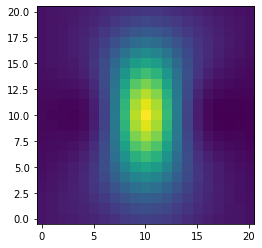

In [30]:
plt.imshow(stack, origin='lower')